# Debug Hybrid Clustering

Simple notebook to analyze inner cluster distances.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import hdbscan
from PIL import Image
import io, base64
from IPython.display import display, HTML

sys.path.insert(0, str(Path.cwd().parent))

RESULTS_DIR = Path("../results/face_clustering_benchmark")
npy_files = sorted(RESULTS_DIR.glob("embeddings_*.npy"), reverse=True)
EMBEDDINGS_FILE = npy_files[0]
embeddings = np.load(EMBEDDINGS_FILE)
embeddings = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)

def cosine_distance_matrix(X, Y=None):
    if Y is None: Y = X
    return np.clip(1 - X @ Y.T, 0, 2).astype(np.float64)

dist_matrix = cosine_distance_matrix(embeddings)
print(f"{len(embeddings)} faces loaded from {EMBEDDINGS_FILE.name}")

274 faces loaded from embeddings_2026-02-20_10-19-23.npy


In [2]:
def compute_all_cluster_stats(labels, k=3):
    cluster_ids = sorted([c for c in set(labels) if c >= 0])
    rows = []
    for cid in cluster_ids:
        cluster_emb = embeddings[labels == cid]
        if len(cluster_emb) < 2:
            continue
        dists = cosine_distance_matrix(cluster_emb)
        upper_tri = dists[np.triu_indices_from(dists, k=1)]
        k_actual = min(k, len(cluster_emb) - 1)
        d3_values = np.array([np.sort(dists[i])[1:k_actual + 1][-1] for i in range(len(cluster_emb))])
        median = np.median(d3_values)
        q1, q3 = np.percentile(d3_values, [25, 75])
        iqr = q3 - q1
        rows.append({
            'cluster': cid,
            'n': len(cluster_emb),
            'd3_min': d3_values.min(),
            'd3_p10': np.percentile(d3_values, 10),
            'd3_med': median,
            'd3_p90': np.percentile(d3_values, 90),
            'd3_max': d3_values.max(),
            'pw_min': upper_tri.min(),
            'pw_p10': np.percentile(upper_tri, 10),
            'pw_med': np.median(upper_tri),
            'pw_p90': np.percentile(upper_tri, 90),
            'pw_max': upper_tri.max(),
            't_med_iqr': median + 1.5 * iqr,
            't_p90': np.percentile(d3_values, 90),
        })
    return pd.DataFrame(rows)

def get_face_image(face_idx):
    crops_dir = RESULTS_DIR / "face_crops"
    for pattern in [f"face_{face_idx:04d}_aligned.jpg", f"face_{face_idx:04d}.jpg"]:
        if (crops_dir / pattern).exists():
            return Image.open(crops_dir / pattern)
    return None

def show_faces(face_indices, size=60):
    html = '<div style="display:flex;flex-wrap:wrap;gap:2px;">'
    for idx in face_indices[:20]:
        img = get_face_image(idx)
        if img:
            img = img.resize((size, size))
            buffer = io.BytesIO()
            img.save(buffer, format='JPEG')
            b64 = base64.b64encode(buffer.getvalue()).decode()
            html += f'<img src="data:image/jpeg;base64,{b64}" title="#{idx}" style="border-radius:3px;">'
    html += '</div>'
    display(HTML(html))

print("Ready")

Ready


In [3]:
# Test HDBSCAN configs
configs = [
    {'name': 'No merge (leaf)', 'eps': 0.0, 'method': 'leaf'},
    {'name': 'Tight (eps=0.045)', 'eps': 0.045, 'method': 'eom'},
    {'name': 'Loose (eps=0.06)', 'eps': 0.06, 'method': 'eom'},
]

results = []
for cfg in configs:
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=2, min_samples=2, metric='precomputed',
        cluster_selection_epsilon=cfg['eps'],
        cluster_selection_method=cfg['method']
    )
    labels = clusterer.fit_predict(dist_matrix)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int(np.sum(labels == -1))
    results.append({'name': cfg['name'], 'labels': labels, 'n_clusters': n_clusters, 'n_noise': n_noise})

df_configs = pd.DataFrame([{'config': r['name'], 'clusters': r['n_clusters'], 'noise': r['n_noise']} for r in results])
display(df_configs)

,config,clusters,noise
0,No merge (leaf),24,168
1,Tight (eps=0.045),8,23
2,Loose (eps=0.06),8,23


In [4]:
# Select config and show inner distance statistics
selected_idx = 1  # 0, 1, or 2
labels = results[selected_idx]['labels']

print(f"\n{results[selected_idx]['name']}\n")
df_stats = compute_all_cluster_stats(labels, k=3)
display(df_stats.round(4))


Tight (eps=0.045)



,cluster,n,d3_min,d3_p10,d3_med,d3_p90,d3_max,pw_min,pw_p10,pw_med,pw_p90,pw_max,t_med_iqr,t_p90
0,0,6,0.4549,0.4912,0.6194,0.6774,0.6870,0.3304,0.3935,0.6001,0.7309,0.8300,0.7916,0.6774
1,1,3,0.0829,0.0846,0.0916,0.0916,0.0916,0.0553,0.0608,0.0829,0.0899,0.0916,0.0981,0.0916
2,2,40,0.1047,0.1760,0.2632,0.5173,0.6400,0.0395,0.2615,0.4769,0.7155,0.9002,0.5484,0.5173
3,3,3,0.3886,0.4037,0.4640,0.4640,0.4640,0.3578,0.3640,0.3886,0.4489,0.4640,0.5205,0.4640
4,4,7,0.1584,0.1761,0.1881,0.2847,0.3326,0.1211,0.1378,0.2102,0.3455,0.3509,0.2380,0.2847
5,5,4,0.1760,0.1773,0.1908,0.2012,0.2012,0.1442,0.1463,0.1688,0.1908,0.2012,0.2237,0.2012
6,6,161,0.1506,0.2221,0.3608,0.5407,0.6214,0.0581,0.4482,0.6559,0.8104,1.0794,0.6521,0.5407
7,7,27,0.2397,0.2811,0.3791,0.5452,0.6120,0.1997,0.3488,0.5424,0.7366,0.9222,0.5745,0.5452


Cluster 0: 6 faces



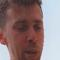
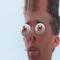
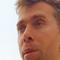
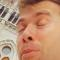
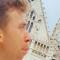
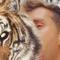

In [5]:
# Show faces for a specific cluster
CLUSTER_ID = 0
members = np.where(labels == CLUSTER_ID)[0]
print(f"Cluster {CLUSTER_ID}: {len(members)} faces")
show_faces(members)